# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Zafar488/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# PRIORITISING CONTENT REVIEW WITH LEAKAGE-SAFE MACHINE LEARNING

## Abstract

This study asks whether historical search-performance signals can help prioritise content pages for human review.

Using the March 2026 FlyRank ML Internship warehouse partition, I created one anonymised client-page row from an earlier feature window and a later outcome window.

A transparent Week-4 rule baseline and a Logistic Regression model were evaluated on the same grouped-client holdout with zero client overlap.

The model is compared with the baseline using Precision@50, Average Precision, and ROC-AUC, and its validated scores are converted into a ranked content action playbook.

The results are observational and directional and are intended for human decision-support rather than automatic publishing, causal claims, or guaranteed performance improvement.

**Lane:** Refresh / Content Opportunity Scoring  
**Unit of analysis:** One anonymised content page for one anonymised client  
**Primary metric:** Precision@50  
**Feature window:** March 1–15, 2026  
**Outcome window:** March 16–31, 2026  
**Author:** Zafar Ullah

## Research Page Design Choices

Before assembling the paper, I reviewed the repository research-paper guidance and public web-accessibility and GitHub Pages guidance.

The deployed paper will use:

- a clear abstract at the top;
- short paragraphs and descriptive headings;
- one primary message per chart;
- captions that explain both the finding and its limitation;
- high-contrast text and accessible image descriptions;
- responsive tables and figures;
- relative paths for CSS and images;
- a static page deployed from the repository's `docs/` folder.

The paper will follow this order:

1. Abstract
2. Introduction and problem
3. Data
4. Methodology
5. Results
6. Limitations
7. Ranked recommendations
8. Reproducibility
9. Acknowledgments and data credit

In [1]:
ABSTRACT_SENTENCES = [
    (
        "This study asks whether historical search-performance signals "
        "can help prioritise content pages for human review."
    ),
    (
        "Using the March 2026 FlyRank ML Internship warehouse partition, "
        "I created one anonymised client-page row from an earlier feature "
        "window and a later outcome window."
    ),
    (
        "A transparent Week-4 rule baseline and a Logistic Regression "
        "model were evaluated on the same grouped-client holdout with "
        "zero client overlap."
    ),
    (
        "The model is compared with the baseline using Precision@50, "
        "Average Precision, and ROC-AUC, and its validated scores are "
        "converted into a ranked content action playbook."
    ),
    (
        "The results are observational and directional and are intended "
        "for human decision-support rather than automatic publishing, "
        "causal claims, or guaranteed performance improvement."
    ),
]

DESIGN_RESEARCH_RECEIPT = {
    "structure": "Canonical research-paper structure",
    "reading_style": "Short paragraphs and descriptive headings",
    "charts": "One finding and one limitation per chart",
    "accessibility": "High contrast, alt text, responsive layout",
    "deployment": "GitHub Pages using docs/ and relative paths",
}

assert len(ABSTRACT_SENTENCES) == 5

print("Five-sentence abstract verified.")
print(DESIGN_RESEARCH_RECEIPT)

Five-sentence abstract verified.
{'structure': 'Canonical research-paper structure', 'reading_style': 'Short paragraphs and descriptive headings', 'charts': 'One finding and one limitation per chart', 'accessibility': 'High contrast, alt text, responsive layout', 'deployment': 'GitHub Pages using docs/ and relative paths'}


## 1. Question

### Research question

Can historical, prediction-time search-performance signals rank eligible content pages so that the first 50 pages reviewed by a human team contain a higher observed future-decline rate than a transparent fixed-rule baseline?

### Decision supported

The output supports this operational decision:

> Which eligible pages should a human content team inspect first, and what type of review appears most reasonable?

The goal is prioritisation rather than automatic editing.

A model score is useful only when it becomes a transparent review queue containing:

- ranked pages;
- reason codes;
- suggested actions;
- confidence notes;
- known limitations;
- mandatory human review.

In [2]:
%pip install -q \
    duckdb \
    huggingface_hub \
    scikit-learn \
    pandas \
    numpy \
    matplotlib \
    joblib

In [3]:
from __future__ import annotations

import json
import os
import shutil
import subprocess
from pathlib import Path
from typing import Any

import duckdb
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from google.colab import userdata
from huggingface_hub import whoami

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)


# ============================================================
# RESEARCH QUESTION
# ============================================================

RESEARCH_QUESTION = (
    "Can historical prediction-time search-performance signals "
    "rank eligible content pages so that the first 50 "
    "human-reviewed pages contain a higher observed "
    "future-decline rate than a transparent fixed-rule baseline?"
)

SUPPORTED_DECISION = (
    "Which eligible pages should a human content team inspect "
    "first, and what type of review appears most reasonable?"
)

PRIMARY_METRIC = "Precision@50"

SEED = 42
TEST_SIZE = 0.20
TOP_K = 50

np.random.seed(SEED)


# ============================================================
# REPOSITORY
# ============================================================

REPO_URL = (
    "https://github.com/"
    "Zafar488/flyrank-ml-internship"
)

REPO_ROOT = Path(
    "/content/flyrank-ml-internship"
)

if Path.cwd().name == "flyrank-ml-internship":

    REPO_ROOT = Path.cwd()

elif not REPO_ROOT.exists():

    print(
        "Repository not found. "
        "Cloning repository..."
    )

    subprocess.run(
        [
            "git",
            "clone",
            "--depth",
            "1",
            REPO_URL,
            str(REPO_ROOT),
        ],
        check=True,
    )

os.chdir(REPO_ROOT)


# ============================================================
# OUTPUT DIRECTORIES
# ============================================================

OUTPUT_DIR = Path(
    "work/outputs/capstone"
)

FIGURE_DIR = Path(
    "work/figures"
)

MODEL_DIR = (
    OUTPUT_DIR
    / "models"
)

DOCS_ASSET_DIR = Path(
    "docs/assets"
)

for directory in [
    OUTPUT_DIR,
    FIGURE_DIR,
    MODEL_DIR,
    DOCS_ASSET_DIR,
]:

    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


# ============================================================
# QUESTION RECEIPT
# ============================================================

question_receipt = pd.DataFrame(
    [
        {
            "research_question": RESEARCH_QUESTION,
            "supported_decision": SUPPORTED_DECISION,
            "primary_metric": PRIMARY_METRIC,
            "automatic_decision": False,
            "human_review_required": True,
        }
    ]
)

display(question_receipt)

assert question_receipt.loc[
    0,
    "automatic_decision",
] == False

assert question_receipt.loc[
    0,
    "human_review_required",
] == True

print(
    "Repository root:",
    Path.cwd(),
)

print(
    "Capstone outputs:",
    OUTPUT_DIR,
)

Repository not found. Cloning repository...


,research_question,supported_decision,primary_metric,automatic_decision,human_review_required
0,Can historical prediction-time search-performa...,Which eligible pages should a human content te...,Precision@50,False,True


Repository root: /content/flyrank-ml-internship
Capstone outputs: work/outputs/capstone


## 2. Data

### Release and source

This study uses the March 2026 partition of the FlyRank ML Internship warehouse.

The primary source is the anonymised daily content-performance fact table:

`fact_content_daily_performance/month=2026-03/*.parquet`

One analytical row represents one anonymised content page for one anonymised client.

### Time windows

- Feature window: March 1–15, 2026
- Outcome window: March 16–31, 2026

### Operational population

A page is included only when it has:

- at least 500 feature-window impressions;
- at least five feature-window available days;
- at least five outcome-window available days;
- average position greater than 0 and no greater than 20;
- valid feature-window CTR;
- a valid position band.

### Public-safe exclusions

The public paper excludes:

- client names;
- raw page URLs;
- private search queries;
- API tokens;
- direct business identifiers.

`client_hash_id` is used only for grouped validation.

`content_hash_id` is used only for deduplication and operational joining.

Neither identifier is used as a predictive model feature.

In [4]:
# ============================================================
# HUGGING FACE AUTHENTICATION
# ============================================================

HF_TOKEN = userdata.get(
    "HF_TOKEN"
)

if not HF_TOKEN:

    raise ValueError(
        "HF_TOKEN was not found. "
        "Add HF_TOKEN in Colab Secrets "
        "and enable notebook access."
    )

whoami(
    token=HF_TOKEN
)

print(
    "Hugging Face authentication successful."
)


# ============================================================
# DUCKDB CONNECTION
# ============================================================

con = duckdb.connect()

safe_token = HF_TOKEN.replace(
    "'",
    "''",
)

con.execute(
    f"""
    CREATE OR REPLACE SECRET hf (
        TYPE huggingface,
        TOKEN '{safe_token}'
    )
    """
)

WAREHOUSE_ROOT = (
    "hf://datasets/"
    "FlyRank/internship-warehouse"
)

MARCH_FACT = (
    "read_parquet("
    f"'{WAREHOUSE_ROOT}/"
    "fact_content_daily_performance/"
    "month=2026-03/*.parquet'"
    ")"
)

print(
    "Feature window: "
    "2026-03-01 to 2026-03-15"
)

print(
    "Outcome window: "
    "2026-03-16 to 2026-03-31"
)

Hugging Face authentication successful.
Feature window: 2026-03-01 to 2026-03-15
Outcome window: 2026-03-16 to 2026-03-31


In [5]:
source_check = con.sql(
    f"""
    SELECT
        COUNT(*) AS total_rows,

        MIN(
            report_date
        ) AS minimum_date,

        MAX(
            report_date
        ) AS maximum_date,

        COUNT(
            DISTINCT client_hash_id
        ) AS unique_clients,

        COUNT(
            DISTINCT (
                client_hash_id,
                content_hash_id
            )
        ) AS unique_client_pages

    FROM {MARCH_FACT}
    """
).df()

display(
    source_check
)

minimum_date = pd.to_datetime(
    source_check.loc[
        0,
        "minimum_date",
    ]
).date()

maximum_date = pd.to_datetime(
    source_check.loc[
        0,
        "maximum_date",
    ]
).date()

assert str(minimum_date) == (
    "2026-03-01"
)

assert str(maximum_date) == (
    "2026-03-31"
)

print(
    "March 2026 source verification passed."
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_rows,minimum_date,maximum_date,unique_clients,unique_client_pages
0,9841378,2026-03-01,2026-03-31,55,331437


March 2026 source verification passed.


In [6]:
page_frame = con.sql(
    f"""
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(
            CASE
                WHEN report_date BETWEEN
                     DATE '2026-03-01'
                     AND DATE '2026-03-15'

                 AND gsc_data_available IS TRUE

                THEN COALESCE(
                    gsc_impressions,
                    0
                )

                ELSE 0
            END
        ) AS feature_impressions,

        SUM(
            CASE
                WHEN report_date BETWEEN
                     DATE '2026-03-01'
                     AND DATE '2026-03-15'

                 AND gsc_data_available IS TRUE

                THEN COALESCE(
                    gsc_clicks,
                    0
                )

                ELSE 0
            END
        ) AS feature_clicks,

        AVG(
            CASE
                WHEN report_date BETWEEN
                     DATE '2026-03-01'
                     AND DATE '2026-03-15'

                 AND gsc_data_available IS TRUE

                THEN gsc_avg_position
            END
        ) AS feature_avg_position,

        STDDEV_SAMP(
            CASE
                WHEN report_date BETWEEN
                     DATE '2026-03-01'
                     AND DATE '2026-03-15'

                 AND gsc_data_available IS TRUE

                THEN gsc_avg_position
            END
        ) AS feature_position_volatility,

        COUNT(
            DISTINCT CASE
                WHEN report_date BETWEEN
                     DATE '2026-03-01'
                     AND DATE '2026-03-15'

                 AND gsc_data_available IS TRUE

                 AND COALESCE(
                     gsc_impressions,
                     0
                 ) > 0

                THEN report_date
            END
        ) AS feature_active_days,

        COUNT(
            DISTINCT CASE
                WHEN report_date BETWEEN
                     DATE '2026-03-01'
                     AND DATE '2026-03-15'

                 AND gsc_data_available IS TRUE

                THEN report_date
            END
        ) AS feature_available_days,

        SUM(
            CASE
                WHEN report_date BETWEEN
                     DATE '2026-03-16'
                     AND DATE '2026-03-31'

                 AND gsc_data_available IS TRUE

                THEN COALESCE(
                    gsc_impressions,
                    0
                )

                ELSE 0
            END
        ) AS outcome_impressions,

        COUNT(
            DISTINCT CASE
                WHEN report_date BETWEEN
                     DATE '2026-03-16'
                     AND DATE '2026-03-31'

                 AND gsc_data_available IS TRUE

                THEN report_date
            END
        ) AS outcome_available_days

    FROM {MARCH_FACT}

    GROUP BY
        client_hash_id,
        content_hash_id
    """
).df()

print(
    "Raw page rows:",
    f"{len(page_frame):,}",
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Raw page rows: 331,437


In [7]:
# ============================================================
# FEATURE-WINDOW CTR
# ============================================================

page_frame[
    "feature_ctr"
] = np.where(
    page_frame[
        "feature_impressions"
    ] > 0,

    page_frame[
        "feature_clicks"
    ]
    /
    page_frame[
        "feature_impressions"
    ],

    np.nan,
)


# ============================================================
# POSITION VOLATILITY
# ============================================================

volatility_median = page_frame[
    "feature_position_volatility"
].median()

if pd.isna(
    volatility_median
):

    volatility_median = 0.0

page_frame[
    "feature_position_volatility"
] = (
    page_frame[
        "feature_position_volatility"
    ]
    .fillna(
        float(
            volatility_median
        )
    )
)


# ============================================================
# DAILY IMPRESSION NORMALISATION
# ============================================================

page_frame[
    "feature_daily_impressions"
] = np.where(
    page_frame[
        "feature_available_days"
    ] > 0,

    page_frame[
        "feature_impressions"
    ]
    /
    page_frame[
        "feature_available_days"
    ],

    np.nan,
)

page_frame[
    "outcome_daily_impressions"
] = np.where(
    page_frame[
        "outcome_available_days"
    ] > 0,

    page_frame[
        "outcome_impressions"
    ]
    /
    page_frame[
        "outcome_available_days"
    ],

    np.nan,
)


# ============================================================
# LABEL
# ============================================================

page_frame[
    "is_declining_proxy"
] = (
    page_frame[
        "outcome_daily_impressions"
    ]
    <
    0.80
    *
    page_frame[
        "feature_daily_impressions"
    ]
).astype(int)


# ============================================================
# DERIVED FEATURES
# ============================================================

page_frame[
    "log_feature_impressions"
] = np.log1p(
    page_frame[
        "feature_impressions"
    ]
)

page_frame[
    "position_band"
] = pd.cut(
    page_frame[
        "feature_avg_position"
    ],
    bins=[
        0,
        3,
        10,
        20,
    ],
    labels=[
        "Top 3",
        "Page 1",
        "Page 2",
    ],
    include_lowest=True,
)


# ============================================================
# OPERATIONAL POPULATION
# ============================================================

model_frame = page_frame[
    (
        page_frame[
            "feature_impressions"
        ] >= 500
    )
    &
    (
        page_frame[
            "feature_available_days"
        ] >= 5
    )
    &
    (
        page_frame[
            "outcome_available_days"
        ] >= 5
    )
    &
    (
        page_frame[
            "feature_avg_position"
        ] > 0
    )
    &
    (
        page_frame[
            "feature_avg_position"
        ] <= 20
    )
    &
    (
        page_frame[
            "feature_ctr"
        ].notna()
    )
    &
    (
        page_frame[
            "position_band"
        ].notna()
    )
].copy()

model_frame = (
    model_frame
    .drop_duplicates(
        subset=[
            "client_hash_id",
            "content_hash_id",
        ]
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# DATA RECEIPT
# ============================================================

data_receipt = pd.DataFrame(
    [
        {
            "release": "March 2026",
            "source_rows": int(
                source_check.loc[
                    0,
                    "total_rows",
                ]
            ),
            "unique_anonymised_clients": int(
                source_check.loc[
                    0,
                    "unique_clients",
                ]
            ),
            "unique_client_page_pairs": int(
                source_check.loc[
                    0,
                    "unique_client_pages",
                ]
            ),
            "operational_model_rows": int(
                len(
                    model_frame
                )
            ),
            "feature_window": (
                "2026-03-01 to 2026-03-15"
            ),
            "outcome_window": (
                "2026-03-16 to 2026-03-31"
            ),
            "declining_proxy_rate": float(
                model_frame[
                    "is_declining_proxy"
                ].mean()
            ),
        }
    ]
)

display(
    data_receipt
)

print(
    "Operational rows:",
    f"{len(model_frame):,}",
)

print(
    "Declining-proxy rate:",
    round(
        model_frame[
            "is_declining_proxy"
        ].mean(),
        3,
    ),
)

assert len(
    model_frame
) > 0

assert model_frame[
    "feature_impressions"
].ge(
    500
).all()

assert model_frame[
    "feature_available_days"
].ge(
    5
).all()

assert model_frame[
    "outcome_available_days"
].ge(
    5
).all()

data_receipt.to_csv(
    OUTPUT_DIR
    / "capstone_data_receipt.csv",
    index=False,
)

,release,source_rows,unique_anonymised_clients,unique_client_page_pairs,operational_model_rows,feature_window,outcome_window,declining_proxy_rate
0,March 2026,9841378,55,331437,34038,2026-03-01 to 2026-03-15,2026-03-16 to 2026-03-31,0.308978


Operational rows: 34,038
Declining-proxy rate: 0.309


## 3. Methodology

### Assumptions

Feature-window measurements must be available at scoring time.

Outcome-window measurements are used only to create and evaluate the later decline proxy.

The target is a directional proxy rather than a direct measure of editorial quality or causal content decay.

### Label definition

A page receives `is_declining_proxy = 1` when its average daily impressions in the outcome window are below 80% of its average daily impressions in the feature window.

### Model features

The Logistic Regression model uses:

- log-transformed feature impressions;
- feature clicks;
- feature CTR;
- average search position;
- active impression days;
- position volatility;
- position band.

### Transparent baseline

The Week-4 baseline uses:

- CTR weakness relative to the position-band median;
- visibility percentile;
- position-volatility percentile.

The score is:

- 60% CTR weakness;
- 30% visibility;
- 10% volatility.

### Validation design

The final validation uses a grouped-client holdout.

Every anonymised client appears entirely in either training or validation.

### Leakage checks

The following are excluded from model features:

- target values;
- outcome-window values;
- client identifiers;
- content identifiers;
- existing baseline scores.

In [8]:
numeric_features = [
    "log_feature_impressions",
    "feature_clicks",
    "feature_ctr",
    "feature_avg_position",
    "feature_active_days",
    "feature_position_volatility",
]

categorical_features = [
    "position_band",
]

feature_columns = (
    numeric_features
    +
    categorical_features
)

target_column = (
    "is_declining_proxy"
)

group_column = (
    "client_hash_id"
)


# ============================================================
# PREPROCESSING
# ============================================================

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            ),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            ),
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features,
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features,
        ),
    ],
    remainder="drop",
)


def build_model() -> Pipeline:
    return Pipeline(
        steps=[
            (
                "preprocessor",
                clone(
                    preprocessor
                ),
            ),
            (
                "classifier",
                LogisticRegression(
                    max_iter=2000,
                    class_weight="balanced",
                    random_state=SEED,
                ),
            ),
        ]
    )


# ============================================================
# GROUPED VALIDATION
# ============================================================

group_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=TEST_SIZE,
    random_state=SEED,
)

train_indices, validation_indices = next(
    group_splitter.split(
        model_frame[
            feature_columns
        ],
        model_frame[
            target_column
        ],
        groups=model_frame[
            group_column
        ],
    )
)

train_frame = (
    model_frame
    .iloc[
        train_indices
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

validation_frame = (
    model_frame
    .iloc[
        validation_indices
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

train_clients = set(
    train_frame[
        group_column
    ].unique()
)

validation_clients = set(
    validation_frame[
        group_column
    ].unique()
)

client_overlap = len(
    train_clients.intersection(
        validation_clients
    )
)

assert client_overlap == 0

print(
    "Training rows:",
    f"{len(train_frame):,}",
)

print(
    "Validation rows:",
    f"{len(validation_frame):,}",
)

print(
    "Grouped client overlap:",
    client_overlap,
)

Training rows: 18,081
Validation rows: 15,957
Grouped client overlap: 0


In [9]:
model = build_model()

model.fit(
    train_frame[
        feature_columns
    ],
    train_frame[
        target_column
    ],
)

model_scores = model.predict_proba(
    validation_frame[
        feature_columns
    ]
)[:, 1]

assert np.isfinite(
    model_scores
).all()

print(
    "Logistic Regression trained successfully."
)

Logistic Regression trained successfully.


In [10]:
# ============================================================
# POSITION-BAND CTR REFERENCE FROM TRAINING DATA
# ============================================================

train_for_baseline = train_frame.copy()

validation_for_baseline = validation_frame.copy()

train_for_baseline[
    "position_band_text"
] = (
    train_for_baseline[
        "position_band"
    ]
    .astype(str)
)

validation_for_baseline[
    "position_band_text"
] = (
    validation_for_baseline[
        "position_band"
    ]
    .astype(str)
)

train_ctr_reference = (
    train_for_baseline
    .groupby(
        "position_band_text"
    )[
        "feature_ctr"
    ]
    .median()
    .to_dict()
)

global_train_ctr_median = float(
    train_for_baseline[
        "feature_ctr"
    ].median()
)

validation_for_baseline[
    "expected_ctr_for_band"
] = (
    validation_for_baseline[
        "position_band_text"
    ]
    .map(
        train_ctr_reference
    )
    .fillna(
        global_train_ctr_median
    )
    .astype(float)
)

validation_for_baseline[
    "ctr_gap"
] = (
    validation_for_baseline[
        "feature_ctr"
    ]
    -
    validation_for_baseline[
        "expected_ctr_for_band"
    ]
)


# ============================================================
# EMPIRICAL TRAINING PERCENTILE
# ============================================================

def empirical_percentile(
    values: Any,
    reference_values: Any,
) -> np.ndarray:

    values_array = np.asarray(
        values,
        dtype=float,
    )

    reference_array = np.sort(
        np.asarray(
            reference_values,
            dtype=float,
        )
    )

    if len(
        reference_array
    ) == 0:

        raise ValueError(
            "Reference distribution cannot be empty."
        )

    return (
        np.searchsorted(
            reference_array,
            values_array,
            side="right",
        )
        /
        len(
            reference_array
        )
    )


validation_for_baseline[
    "visibility_score"
] = empirical_percentile(
    validation_for_baseline[
        "feature_impressions"
    ],
    train_for_baseline[
        "feature_impressions"
    ],
)

validation_for_baseline[
    "volatility_score"
] = empirical_percentile(
    validation_for_baseline[
        "feature_position_volatility"
    ],
    train_for_baseline[
        "feature_position_volatility"
    ],
)


# ============================================================
# CTR WEAKNESS
# ============================================================

validation_for_baseline[
    "ctr_weakness_score"
] = np.where(
    validation_for_baseline[
        "expected_ctr_for_band"
    ] > 0,

    (
        -validation_for_baseline[
            "ctr_gap"
        ]
        /
        validation_for_baseline[
            "expected_ctr_for_band"
        ]
    ),

    0.0,
)

validation_for_baseline[
    "ctr_weakness_score"
] = (
    validation_for_baseline[
        "ctr_weakness_score"
    ]
    .clip(
        lower=0.0,
        upper=1.0,
    )
)


# ============================================================
# BASELINE SCORE
# ============================================================

validation_for_baseline[
    "baseline_eligible"
] = (
    validation_for_baseline[
        "ctr_gap"
    ] < 0
)

validation_for_baseline[
    "baseline_raw_score"
] = (
    100
    *
    (
        0.60
        *
        validation_for_baseline[
            "ctr_weakness_score"
        ]
        +
        0.30
        *
        validation_for_baseline[
            "visibility_score"
        ]
        +
        0.10
        *
        validation_for_baseline[
            "volatility_score"
        ]
    )
)

baseline_scores = np.where(
    validation_for_baseline[
        "baseline_eligible"
    ],
    validation_for_baseline[
        "baseline_raw_score"
    ],
    0.0,
).astype(float)

assert np.isfinite(
    baseline_scores
).all()

print(
    "Baseline eligible validation rows:",
    int(
        validation_for_baseline[
            "baseline_eligible"
        ].sum()
    ),
)

print(
    "Week-4 baseline recreated on the grouped holdout."
)

Baseline eligible validation rows: 8161
Week-4 baseline recreated on the grouped holdout.


In [11]:
leakage_audit = pd.DataFrame(
    [
        {
            "field": "log_feature_impressions",
            "role": "model feature",
            "safe_for_model": True,
            "reason": (
                "Feature-window information only"
            ),
        },
        {
            "field": "feature_clicks",
            "role": "model feature",
            "safe_for_model": True,
            "reason": (
                "Feature-window information only"
            ),
        },
        {
            "field": "feature_ctr",
            "role": "model feature",
            "safe_for_model": True,
            "reason": (
                "Feature-window information only"
            ),
        },
        {
            "field": "feature_avg_position",
            "role": "model feature",
            "safe_for_model": True,
            "reason": (
                "Feature-window information only"
            ),
        },
        {
            "field": "feature_active_days",
            "role": "model feature",
            "safe_for_model": True,
            "reason": (
                "Feature-window information only"
            ),
        },
        {
            "field": "feature_position_volatility",
            "role": "model feature",
            "safe_for_model": True,
            "reason": (
                "Feature-window information only"
            ),
        },
        {
            "field": "position_band",
            "role": "model feature",
            "safe_for_model": True,
            "reason": (
                "Derived from feature-window position"
            ),
        },
        {
            "field": "client_hash_id",
            "role": "group identifier",
            "safe_for_model": False,
            "reason": (
                "Used only for grouped validation"
            ),
        },
        {
            "field": "content_hash_id",
            "role": "operational identifier",
            "safe_for_model": False,
            "reason": (
                "Used only for joining and deduplication"
            ),
        },
        {
            "field": "outcome_impressions",
            "role": "target construction",
            "safe_for_model": False,
            "reason": (
                "Future outcome-window information"
            ),
        },
        {
            "field": "outcome_daily_impressions",
            "role": "target construction",
            "safe_for_model": False,
            "reason": (
                "Future outcome-window information"
            ),
        },
        {
            "field": "is_declining_proxy",
            "role": "target",
            "safe_for_model": False,
            "reason": (
                "This is the prediction target"
            ),
        },
        {
            "field": "baseline_action_score",
            "role": "existing score",
            "safe_for_model": False,
            "reason": (
                "Comparison baseline only"
            ),
        },
    ]
)

display(
    leakage_audit
)

assert target_column not in feature_columns

assert group_column not in feature_columns

assert "content_hash_id" not in feature_columns

assert "outcome_impressions" not in feature_columns

assert (
    "outcome_daily_impressions"
    not in feature_columns
)

assert (
    "baseline_action_score"
    not in feature_columns
)

print(
    "Leakage audit passed."
)

,field,role,safe_for_model,reason
0,log_feature_impressions,model feature,True,Feature-window information only
1,feature_clicks,model feature,True,Feature-window information only
2,feature_ctr,model feature,True,Feature-window information only
3,feature_avg_position,model feature,True,Feature-window information only
4,feature_active_days,model feature,True,Feature-window information only
5,feature_position_volatility,model feature,True,Feature-window information only
6,position_band,model feature,True,Derived from feature-window position
7,client_hash_id,group identifier,False,Used only for grouped validation
8,content_hash_id,operational identifier,False,Used only for joining and deduplication
9,outcome_impressions,target construction,False,Future outcome-window information


Leakage audit passed.


## 4. Results (vs baseline)

The transparent Week-4 baseline and Logistic Regression model are evaluated on the same grouped-client validation rows.

Precision@50 is the primary metric because the content-review team has limited capacity.

The validation base rate is reported to provide context.

Average Precision and ROC-AUC are supporting ranking metrics.

A better measured ranking result supports prioritisation on this holdout. It does not guarantee the same result for every client, market, language, or future time period.

In [12]:
def prepare_ranking_arrays(
    labels: Any,
    scores: Any,
) -> tuple[
    np.ndarray,
    np.ndarray,
]:
    labels_array = np.asarray(
        labels,
        dtype=int,
    )

    scores_array = np.asarray(
        scores,
        dtype=float,
    )

    if labels_array.ndim != 1:

        raise ValueError(
            "Labels must be one-dimensional."
        )

    if scores_array.ndim != 1:

        raise ValueError(
            "Scores must be one-dimensional."
        )

    if len(
        labels_array
    ) != len(
        scores_array
    ):

        raise ValueError(
            "Labels and scores must have equal length."
        )

    if len(
        labels_array
    ) == 0:

        raise ValueError(
            "Evaluation arrays cannot be empty."
        )

    if not np.isfinite(
        scores_array
    ).all():

        raise ValueError(
            "Scores contain NaN or infinite values."
        )

    return (
        labels_array,
        scores_array,
    )


def precision_at_k(
    labels: Any,
    scores: Any,
    k: int = 50,
) -> float:
    labels_array, scores_array = (
        prepare_ranking_arrays(
            labels,
            scores,
        )
    )

    effective_k = min(
        k,
        len(
            labels_array
        ),
    )

    ranked_indices = np.argsort(
        -scores_array,
        kind="mergesort",
    )[:effective_k]

    return float(
        labels_array[
            ranked_indices
        ].mean()
    )


def recall_at_k(
    labels: Any,
    scores: Any,
    k: int = 50,
) -> float:
    labels_array, scores_array = (
        prepare_ranking_arrays(
            labels,
            scores,
        )
    )

    total_positives = int(
        labels_array.sum()
    )

    if total_positives == 0:

        return np.nan

    effective_k = min(
        k,
        len(
            labels_array
        ),
    )

    ranked_indices = np.argsort(
        -scores_array,
        kind="mergesort",
    )[:effective_k]

    return float(
        labels_array[
            ranked_indices
        ].sum()
        /
        total_positives
    )


def top_k_positive_count(
    labels: Any,
    scores: Any,
    k: int = 50,
) -> int:
    labels_array, scores_array = (
        prepare_ranking_arrays(
            labels,
            scores,
        )
    )

    effective_k = min(
        k,
        len(
            labels_array
        ),
    )

    ranked_indices = np.argsort(
        -scores_array,
        kind="mergesort",
    )[:effective_k]

    return int(
        labels_array[
            ranked_indices
        ].sum()
    )

In [13]:
labels = validation_frame[
    target_column
].to_numpy(
    dtype=int
)

validation_base_rate = float(
    labels.mean()
)


# ============================================================
# BASELINE RESULTS
# ============================================================

baseline_result = {
    "method": (
        "Week-4 transparent baseline"
    ),
    "validation_design": (
        "Grouped client holdout"
    ),
    "validation_rows": int(
        len(
            validation_frame
        )
    ),
    "validation_clients": int(
        validation_frame[
            group_column
        ].nunique()
    ),
    "client_overlap": int(
        client_overlap
    ),
    "positive_base_rate": (
        validation_base_rate
    ),
    "precision_at_50": precision_at_k(
        labels,
        baseline_scores,
        TOP_K,
    ),
    "recall_at_50": recall_at_k(
        labels,
        baseline_scores,
        TOP_K,
    ),
    "top_50_positives": top_k_positive_count(
        labels,
        baseline_scores,
        TOP_K,
    ),
    "average_precision": float(
        average_precision_score(
            labels,
            baseline_scores,
        )
    ),
    "roc_auc": float(
        roc_auc_score(
            labels,
            baseline_scores,
        )
    ),
}


# ============================================================
# MODEL RESULTS
# ============================================================

model_result = {
    "method": (
        "Logistic Regression"
    ),
    "validation_design": (
        "Grouped client holdout"
    ),
    "validation_rows": int(
        len(
            validation_frame
        )
    ),
    "validation_clients": int(
        validation_frame[
            group_column
        ].nunique()
    ),
    "client_overlap": int(
        client_overlap
    ),
    "positive_base_rate": (
        validation_base_rate
    ),
    "precision_at_50": precision_at_k(
        labels,
        model_scores,
        TOP_K,
    ),
    "recall_at_50": recall_at_k(
        labels,
        model_scores,
        TOP_K,
    ),
    "top_50_positives": top_k_positive_count(
        labels,
        model_scores,
        TOP_K,
    ),
    "average_precision": float(
        average_precision_score(
            labels,
            model_scores,
        )
    ),
    "roc_auc": float(
        roc_auc_score(
            labels,
            model_scores,
        )
    ),
}


# ============================================================
# COMPARISON TABLE
# ============================================================

results_table = pd.DataFrame(
    [
        baseline_result,
        model_result,
    ]
)

results_table[
    "precision_lift_vs_base_rate"
] = (
    results_table[
        "precision_at_50"
    ]
    -
    results_table[
        "positive_base_rate"
    ]
)

display(
    results_table.round(4)
)

baseline_precision_50 = float(
    baseline_result[
        "precision_at_50"
    ]
)

model_precision_50 = float(
    model_result[
        "precision_at_50"
    ]
)

precision_difference = (
    model_precision_50
    -
    baseline_precision_50
)

print(
    "Validation base rate:",
    round(
        validation_base_rate,
        3,
    ),
)

print(
    "Baseline Precision@50:",
    round(
        baseline_precision_50,
        3,
    ),
)

print(
    "Model Precision@50:",
    round(
        model_precision_50,
        3,
    ),
)

print(
    "Model minus baseline Precision@50:",
    round(
        precision_difference,
        3,
    ),
)

if precision_difference > 0:

    result_interpretation = (
        "The model measured a higher Precision@50 "
        "than the transparent baseline on the same "
        "grouped holdout."
    )

elif np.isclose(
    precision_difference,
    0,
):

    result_interpretation = (
        "The model and transparent baseline measured "
        "the same Precision@50 on this grouped holdout."
    )

else:

    result_interpretation = (
        "The transparent baseline measured a higher "
        "Precision@50 than the model on this grouped holdout."
    )

print(
    result_interpretation
)

results_table.to_csv(
    OUTPUT_DIR
    / "capstone_model_vs_baseline.csv",
    index=False,
)

,method,validation_design,validation_rows,validation_clients,client_overlap,positive_base_rate,precision_at_50,recall_at_50,top_50_positives,average_precision,roc_auc,precision_lift_vs_base_rate
0,Week-4 transparent baseline,Grouped client holdout,15957,7,0,0.3006,0.44,0.0046,22,0.3755,0.6058,0.1394
1,Logistic Regression,Grouped client holdout,15957,7,0,0.3006,0.64,0.0067,32,0.3937,0.6175,0.3394


Validation base rate: 0.301
Baseline Precision@50: 0.44
Model Precision@50: 0.64
Model minus baseline Precision@50: 0.2
The model measured a higher Precision@50 than the transparent baseline on the same grouped holdout.


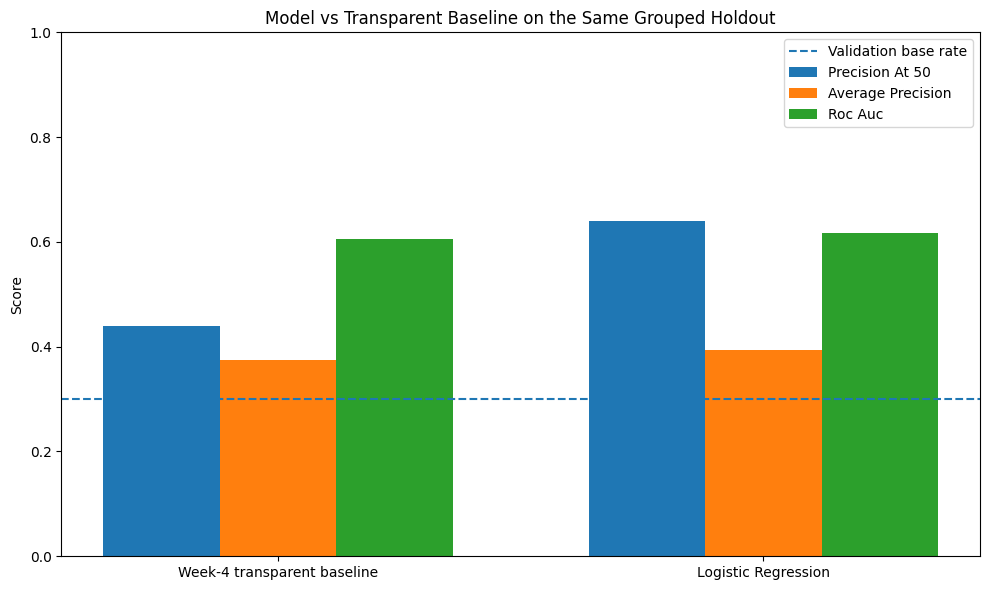

Saved: work/figures/capstone_model_vs_baseline.png


In [14]:
comparison_plot = (
    results_table
    .set_index(
        "method"
    )[
        [
            "precision_at_50",
            "average_precision",
            "roc_auc",
        ]
    ]
)

x_positions = np.arange(
    len(
        comparison_plot.index
    )
)

bar_width = 0.24

plt.figure(
    figsize=(
        10,
        6,
    )
)

for metric_index, metric_name in enumerate(
    comparison_plot.columns
):

    plt.bar(
        x_positions
        +
        (
            metric_index - 1
        )
        *
        bar_width,

        comparison_plot[
            metric_name
        ].values,

        width=bar_width,

        label=metric_name.replace(
            "_",
            " ",
        ).title(),
    )

plt.axhline(
    validation_base_rate,
    linestyle="--",
    linewidth=1.5,
    label="Validation base rate",
)

plt.xticks(
    x_positions,
    comparison_plot.index,
)

plt.ylim(
    0,
    1,
)

plt.ylabel(
    "Score"
)

plt.title(
    "Model vs Transparent Baseline "
    "on the Same Grouped Holdout"
)

plt.legend()

plt.tight_layout()

model_vs_baseline_path = (
    FIGURE_DIR
    / "capstone_model_vs_baseline.png"
)

plt.savefig(
    model_vs_baseline_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    model_vs_baseline_path,
)

,feature,importance_mean,importance_std,stable_positive
0,feature_ctr,0.07416,0.00228,True
1,position_band,0.03470,0.00285,True
2,feature_avg_position,0.01672,0.00278,True
3,feature_position_volatility,0.01290,0.00220,True
4,feature_clicks,0.00014,0.00022,False
5,log_feature_impressions,-0.00052,0.00077,False
6,feature_active_days,-0.00170,0.00039,False


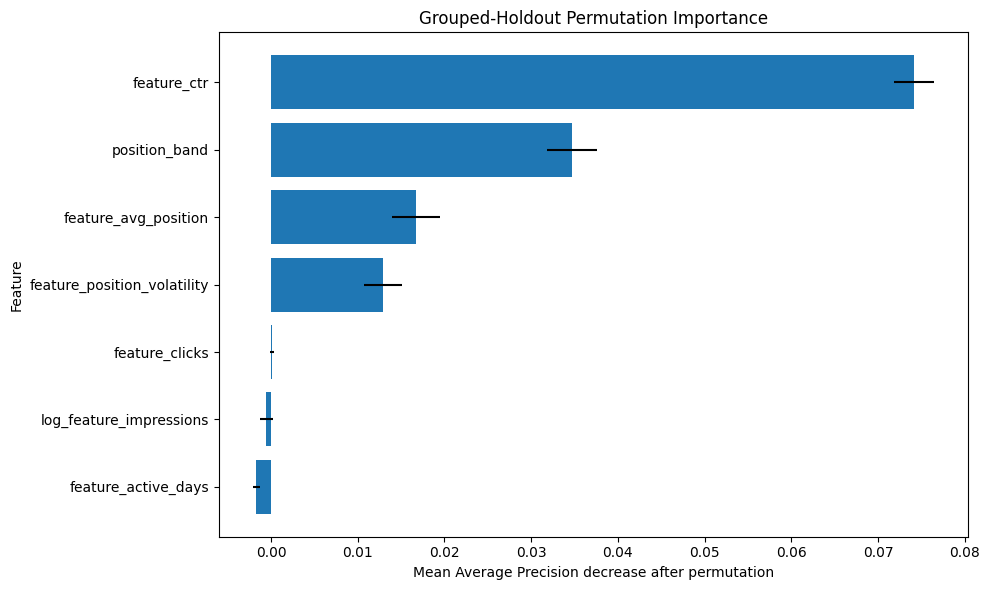

In [15]:
permutation_result = permutation_importance(
    model,

    validation_frame[
        feature_columns
    ],

    validation_frame[
        target_column
    ],

    scoring="average_precision",

    n_repeats=10,

    random_state=SEED,

    n_jobs=-1,
)

importance_table = pd.DataFrame(
    {
        "feature": (
            feature_columns
        ),
        "importance_mean": (
            permutation_result
            .importances_mean
        ),
        "importance_std": (
            permutation_result
            .importances_std
        ),
    }
)

importance_table[
    "stable_positive"
] = (
    importance_table[
        "importance_mean"
    ]
    -
    2
    *
    importance_table[
        "importance_std"
    ]
    > 0
)

importance_table = (
    importance_table
    .sort_values(
        "importance_mean",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)

display(
    importance_table.round(5)
)

plot_importance = (
    importance_table
    .sort_values(
        "importance_mean",
        ascending=True,
    )
)

plt.figure(
    figsize=(
        10,
        6,
    )
)

plt.barh(
    plot_importance[
        "feature"
    ],

    plot_importance[
        "importance_mean"
    ],

    xerr=plot_importance[
        "importance_std"
    ],
)

plt.xlabel(
    "Mean Average Precision decrease "
    "after permutation"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Grouped-Holdout Permutation Importance"
)

plt.tight_layout()

importance_path = (
    FIGURE_DIR
    / "capstone_grouped_permutation_importance.png"
)

plt.savefig(
    importance_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

importance_table.to_csv(
    OUTPUT_DIR
    / "capstone_permutation_importance.csv",
    index=False,
)

In [16]:
model_path = (
    MODEL_DIR
    / "capstone_grouped_logistic_regression.joblib"
)

joblib.dump(
    model,
    model_path,
)

results_receipt = {
    "validation_base_rate": (
        validation_base_rate
    ),
    "baseline": (
        baseline_result
    ),
    "model": (
        model_result
    ),
    "model_minus_baseline_precision_at_50": (
        precision_difference
    ),
    "interpretation": (
        result_interpretation
    ),
    "causal_claim": False,
    "automatic_decision": False,
}

with (
    OUTPUT_DIR
    / "capstone_results_metrics.json"
).open(
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        results_receipt,
        file,
        indent=2,
    )

print(
    "Saved model:",
    model_path,
)

Saved model: work/outputs/capstone/models/capstone_grouped_logistic_regression.joblib


## 5. Limitations

This study uses an observational proxy label rather than a direct measure of editorial quality or causal content decay.

The grouped validation design prevents client overlap, but the reported results come from one grouped holdout and one March 2026 time period.

The model does not observe:

- query-level search intent;
- SERP composition;
- competitor activity;
- technical SEO failures;
- factual accuracy;
- editorial quality;
- conversion value;
- business priority;
- legal, brand, or compliance constraints.

The baseline is adapted honestly by learning its CTR references and percentile distributions from grouped training rows.

The action playbook uses review-effort assumptions rather than measured labour costs or monetary return.

Small action groups should not be interpreted as reliable evidence of expected performance.

This work supports prioritisation and human inspection.

It cannot support automatic publishing, automatic deletion, redirects, title changes, causal claims, or guaranteed recovery.

In [17]:
limitations = pd.DataFrame(
    [
        {
            "limitation": (
                "Observational proxy label"
            ),
            "cannot_claim": (
                "The model identifies true "
                "causal content decay."
            ),
            "safe_framing": (
                "The model ranks pages associated "
                "with a later impression-decline proxy."
            ),
        },
        {
            "limitation": (
                "One grouped holdout"
            ),
            "cannot_claim": (
                "Performance will be identical "
                "for every future client."
            ),
            "safe_framing": (
                "The reported numbers are measured "
                "on one grouped-client holdout."
            ),
        },
        {
            "limitation": (
                "Limited feature view"
            ),
            "cannot_claim": (
                "The model fully explains why "
                "a page changed."
            ),
            "safe_framing": (
                "The score is one decision-support "
                "input alongside page-level review."
            ),
        },
        {
            "limitation": (
                "No intervention experiment"
            ),
            "cannot_claim": (
                "Refreshing a recommended page "
                "will recover traffic."
            ),
            "safe_framing": (
                "Refresh recommendations indicate "
                "review priority, not treatment effect."
            ),
        },
        {
            "limitation": (
                "No monetary outcome"
            ),
            "cannot_claim": (
                "The queue estimates revenue "
                "or financial ROI."
            ),
            "safe_framing": (
                "Visibility and review effort "
                "are planning proxies only."
            ),
        },
        {
            "limitation": (
                "Small archetype groups"
            ),
            "cannot_claim": (
                "Every action-group result "
                "is stable or generalisable."
            ),
            "safe_framing": (
                "Small groups require cautious "
                "interpretation and more evidence."
            ),
        },
    ]
)

display(
    limitations
)

limitations.to_csv(
    OUTPUT_DIR
    / "capstone_limitations.csv",
    index=False,
)

assert len(
    limitations
) >= 5

print(
    "Limitations documented."
)

,limitation,cannot_claim,safe_framing
0,Observational proxy label,The model identifies true causal content decay.,The model ranks pages associated with a later ...
1,One grouped holdout,Performance will be identical for every future...,The reported numbers are measured on one group...
2,Limited feature view,The model fully explains why a page changed.,The score is one decision-support input alongs...
3,No intervention experiment,Refreshing a recommended page will recover tra...,Refresh recommendations indicate review priori...
4,No monetary outcome,The queue estimates revenue or financial ROI.,Visibility and review effort are planning prox...
5,Small archetype groups,Every action-group result is stable or general...,Small groups require cautious interpretation a...


Limitations documented.


## 6. Ranked recommendations

The validated model score is converted into a human-reviewed content action playbook.

### Priority score

The review-priority score uses only prediction-time information:

- 65% model score;
- 25% visibility percentile;
- 10% data-quality proxy.

### Ranked recommendation categories

1. **CTR Review**  
   Inspect high-visibility pages whose CTR is below the training reference for the same position band.

2. **Expand and Optimise**  
   Inspect high-visibility Page-2 pages for intent and coverage gaps.

3. **Refresh Review**  
   Inspect high-risk pages with volatile positions for freshness, technical, intent, and competitor changes.

4. **Refresh and Protect**  
   Review high-risk Page-1 pages conservatively while protecting valuable sections and links.

5. **Protect**  
   Avoid unnecessary edits to low-risk, high-visibility pages.

6. **Monitor**  
   Collect more evidence for borderline or limited-history pages.

7. **Manual Review**  
   Investigate high-risk pages without a clear archetype.

Every action requires human review.

The playbook must never automatically publish, rewrite, delete, redirect, canonicalise, no-index, or change page metadata.

In [18]:
recommendation_frame = validation_frame.copy()

recommendation_frame[
    "model_score"
] = model_scores


# ============================================================
# TRAINING-DERIVED REFERENCES
# ============================================================

train_reference = train_frame.copy()

train_reference[
    "position_band_text"
] = (
    train_reference[
        "position_band"
    ]
    .astype(str)
)

recommendation_frame[
    "position_band_text"
] = (
    recommendation_frame[
        "position_band"
    ]
    .astype(str)
)

training_ctr_reference = (
    train_reference
    .groupby(
        "position_band_text"
    )[
        "feature_ctr"
    ]
    .median()
    .to_dict()
)

training_global_ctr = float(
    train_reference[
        "feature_ctr"
    ].median()
)

training_impression_q75 = float(
    train_reference[
        "feature_impressions"
    ].quantile(
        0.75
    )
)

training_volatility_q75 = float(
    train_reference[
        "feature_position_volatility"
    ].quantile(
        0.75
    )
)

training_volatility_median = float(
    train_reference[
        "feature_position_volatility"
    ].median()
)

recommendation_frame[
    "position_band_ctr_reference"
] = (
    recommendation_frame[
        "position_band_text"
    ]
    .map(
        training_ctr_reference
    )
    .fillna(
        training_global_ctr
    )
    .astype(float)
)


# ============================================================
# PRIORITY COMPONENTS
# ============================================================

recommendation_frame[
    "visibility_value_proxy"
] = empirical_percentile(
    recommendation_frame[
        "feature_impressions"
    ],
    train_reference[
        "feature_impressions"
    ],
)

recommendation_frame[
    "data_quality_proxy"
] = (
    (
        recommendation_frame[
            "feature_active_days"
        ].clip(
            0,
            15,
        )
        /
        15.0
    )
    +
    (
        recommendation_frame[
            "feature_available_days"
        ].clip(
            0,
            15,
        )
        /
        15.0
    )
) / 2.0

recommendation_frame[
    "review_priority_score"
] = (
    100
    *
    (
        0.65
        *
        recommendation_frame[
            "model_score"
        ]
        +
        0.25
        *
        recommendation_frame[
            "visibility_value_proxy"
        ]
        +
        0.10
        *
        recommendation_frame[
            "data_quality_proxy"
        ]
    )
).round(2)

In [19]:
def classify_action(
    row: pd.Series,
) -> pd.Series:
    score = float(
        row[
            "model_score"
        ]
    )

    impressions = float(
        row[
            "feature_impressions"
        ]
    )

    ctr = float(
        row[
            "feature_ctr"
        ]
    )

    position = float(
        row[
            "feature_avg_position"
        ]
    )

    volatility = float(
        row[
            "feature_position_volatility"
        ]
    )

    ctr_reference = float(
        row[
            "position_band_ctr_reference"
        ]
    )

    active_days = int(
        row[
            "feature_active_days"
        ]
    )

    if (
        score >= 0.60
        and position <= 10
        and impressions >= training_impression_q75
        and ctr < ctr_reference
    ):
        return pd.Series(
            {
                "archetype": (
                    "HIGH_VISIBILITY_WEAK_CTR"
                ),
                "action_label": (
                    "CTR_REVIEW"
                ),
                "reason_code": (
                    "CTR_GAP_HIGH_VISIBILITY"
                ),
                "confidence_note": (
                    "High measured risk and strong visibility; "
                    "CTR is below the training reference for "
                    "the same position band."
                ),
            }
        )

    if (
        score >= 0.60
        and 10 < position <= 20
        and impressions >= training_impression_q75
    ):
        return pd.Series(
            {
                "archetype": (
                    "VALUABLE_PAGE_2_OPPORTUNITY"
                ),
                "action_label": (
                    "EXPAND_AND_OPTIMISE"
                ),
                "reason_code": (
                    "HIGH_VALUE_PAGE_2"
                ),
                "confidence_note": (
                    "High measured risk with strong visibility "
                    "in the Page-2 position band."
                ),
            }
        )

    if (
        score >= 0.60
        and volatility >= training_volatility_q75
    ):
        return pd.Series(
            {
                "archetype": (
                    "HIGH_RISK_VOLATILE"
                ),
                "action_label": (
                    "REFRESH_REVIEW"
                ),
                "reason_code": (
                    "HIGH_RISK_HIGH_VOLATILITY"
                ),
                "confidence_note": (
                    "High measured risk with position "
                    "volatility above the training reference."
                ),
            }
        )

    if (
        score >= 0.60
        and position <= 10
        and volatility <= training_volatility_median
    ):
        return pd.Series(
            {
                "archetype": (
                    "HIGH_RISK_STABLE_VISIBILITY"
                ),
                "action_label": (
                    "REFRESH_AND_PROTECT"
                ),
                "reason_code": (
                    "HIGH_RISK_STABLE_VISIBILITY"
                ),
                "confidence_note": (
                    "High measured risk while the page "
                    "retains relatively stable Page-1 visibility."
                ),
            }
        )

    if (
        score < 0.35
        and position <= 10
        and impressions >= training_impression_q75
    ):
        return pd.Series(
            {
                "archetype": (
                    "LOW_RISK_HIGH_VALUE"
                ),
                "action_label": (
                    "PROTECT"
                ),
                "reason_code": (
                    "LOW_RISK_HIGH_VISIBILITY"
                ),
                "confidence_note": (
                    "Low measured risk with strong visibility; "
                    "avoid unnecessary edits."
                ),
            }
        )

    if (
        0.45 <= score < 0.60
        or active_days < 8
    ):
        return pd.Series(
            {
                "archetype": (
                    "BORDERLINE_OR_LOW_DATA"
                ),
                "action_label": (
                    "MONITOR"
                ),
                "reason_code": (
                    "UNCERTAIN_OR_LIMITED_SIGNAL"
                ),
                "confidence_note": (
                    "The score is borderline or historical "
                    "activity is limited."
                ),
            }
        )

    if score >= 0.60:
        return pd.Series(
            {
                "archetype": (
                    "HIGH_RISK_OTHER"
                ),
                "action_label": (
                    "MANUAL_REVIEW"
                ),
                "reason_code": (
                    "HIGH_RISK_NO_CLEAR_ARCHETYPE"
                ),
                "confidence_note": (
                    "High measured risk without a sufficiently "
                    "clear action archetype."
                ),
            }
        )

    return pd.Series(
        {
            "archetype": (
                "LOWER_PRIORITY_OTHER"
            ),
            "action_label": (
                "NO_IMMEDIATE_ACTION"
            ),
            "reason_code": (
                "LOWER_MEASURED_PRIORITY"
            ),
            "confidence_note": (
                "The page does not meet the current "
                "action-review thresholds."
            ),
        }
    )


recommendation_frame[
    [
        "archetype",
        "action_label",
        "reason_code",
        "confidence_note",
    ]
] = recommendation_frame.apply(
    classify_action,
    axis=1,
)

In [20]:
action_cost_map = {
    "CTR_REVIEW": (
        "LOW",
        20,
    ),
    "EXPAND_AND_OPTIMISE": (
        "HIGH",
        120,
    ),
    "REFRESH_REVIEW": (
        "MEDIUM",
        90,
    ),
    "REFRESH_AND_PROTECT": (
        "MEDIUM",
        75,
    ),
    "PROTECT": (
        "LOW",
        15,
    ),
    "MONITOR": (
        "LOW",
        10,
    ),
    "MANUAL_REVIEW": (
        "MEDIUM",
        30,
    ),
    "NO_IMMEDIATE_ACTION": (
        "NONE",
        0,
    ),
}

recommendation_frame[
    "review_cost_tier"
] = recommendation_frame[
    "action_label"
].map(
    lambda action: (
        action_cost_map[
            action
        ][0]
    )
)

recommendation_frame[
    "estimated_review_minutes"
] = recommendation_frame[
    "action_label"
].map(
    lambda action: (
        action_cost_map[
            action
        ][1]
    )
)

recommendation_frame[
    "human_review_required"
] = recommendation_frame[
    "action_label"
].ne(
    "NO_IMMEDIATE_ACTION"
)

ranked_queue = (
    recommendation_frame[
        recommendation_frame[
            "human_review_required"
        ]
    ]
    .copy()
    .sort_values(
        [
            "review_priority_score",
            "model_score",
            "feature_impressions",
        ],
        ascending=[
            False,
            False,
            False,
        ],
        kind="mergesort",
    )
    .reset_index(
        drop=True
    )
)

ranked_queue.insert(
    0,
    "rank",
    np.arange(
        1,
        len(
            ranked_queue
        ) + 1,
    ),
)


# ============================================================
# ACTION SUMMARY
# ============================================================

recommendation_summary = (
    ranked_queue
    .groupby(
        [
            "action_label",
            "reason_code",
        ],
        observed=True,
    )
    .agg(
        pages=(
            "content_hash_id",
            "size",
        ),
        observed_decline_rate=(
            target_column,
            "mean",
        ),
        median_priority=(
            "review_priority_score",
            "median",
        ),
        median_model_score=(
            "model_score",
            "median",
        ),
        total_review_minutes=(
            "estimated_review_minutes",
            "sum",
        ),
    )
    .reset_index()
)

recommendation_summary[
    "observed_decline_rate_pct"
] = (
    100
    *
    recommendation_summary[
        "observed_decline_rate"
    ]
).round(2)

recommendation_summary[
    "estimated_review_hours"
] = (
    recommendation_summary[
        "total_review_minutes"
    ]
    /
    60.0
).round(2)

recommendation_summary = (
    recommendation_summary
    .sort_values(
        [
            "median_priority",
            "pages",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# PUBLIC DISPLAY
# ============================================================

public_queue_columns = [
    "rank",
    "review_priority_score",
    "model_score",
    "action_label",
    "reason_code",
    "archetype",
    "review_cost_tier",
    "estimated_review_minutes",
    "feature_impressions",
    "feature_ctr",
    "feature_avg_position",
    "feature_position_volatility",
    "confidence_note",
]

display(
    ranked_queue[
        public_queue_columns
    ].head(20)
)

display(
    recommendation_summary
)


# ============================================================
# QUEUE EXPORT
# ============================================================

queue_export_columns = [
    "rank",
    "client_hash_id",
    "content_hash_id",
    "review_priority_score",
    "model_score",
    "action_label",
    "reason_code",
    "archetype",
    "review_cost_tier",
    "estimated_review_minutes",
    "human_review_required",
    "feature_impressions",
    "feature_clicks",
    "feature_ctr",
    "feature_avg_position",
    "feature_active_days",
    "feature_available_days",
    "feature_position_volatility",
    "position_band",
    "confidence_note",
]

queue_path = (
    OUTPUT_DIR
    / "capstone_ranked_action_queue.csv"
)

recommendation_summary_path = (
    OUTPUT_DIR
    / "capstone_recommendation_summary.csv"
)

ranked_queue[
    queue_export_columns
].to_csv(
    queue_path,
    index=False,
)

recommendation_summary.to_csv(
    recommendation_summary_path,
    index=False,
)

print(
    "Ranked queue rows:",
    f"{len(ranked_queue):,}",
)

,rank,review_priority_score,model_score,action_label,reason_code,archetype,review_cost_tier,estimated_review_minutes,feature_impressions,feature_ctr,feature_avg_position,feature_position_volatility,confidence_note
0,1,80.60,0.701739,CTR_REVIEW,CTR_GAP_HIGH_VISIBILITY,HIGH_VISIBILITY_WEAK_CTR,LOW,20,83772.0,0.000000,8.607910,12.407646,High measured risk and strong visibility; CTR ...
1,2,79.17,0.691044,CTR_REVIEW,CTR_GAP_HIGH_VISIBILITY,HIGH_VISIBILITY_WEAK_CTR,LOW,20,11060.0,0.000090,8.800659,9.040149,High measured risk and strong visibility; CTR ...
2,3,76.75,0.673788,CTR_REVIEW,CTR_GAP_HIGH_VISIBILITY,HIGH_VISIBILITY_WEAK_CTR,LOW,20,5961.0,0.001342,7.690508,10.759353,High measured risk and strong visibility; CTR ...
3,4,76.56,0.687770,CTR_REVIEW,CTR_GAP_HIGH_VISIBILITY,HIGH_VISIBILITY_WEAK_CTR,LOW,20,4403.0,0.000681,6.243306,10.998859,High measured risk and strong visibility; CTR ...
4,5,75.67,0.644348,CTR_REVIEW,CTR_GAP_HIGH_VISIBILITY,HIGH_VISIBILITY_WEAK_CTR,LOW,20,8352.0,0.000599,5.998680,7.424706,High measured risk and strong visibility; CTR ...
5,6,75.34,0.644513,CTR_REVIEW,CTR_GAP_HIGH_VISIBILITY,HIGH_VISIBILITY_WEAK_CTR,LOW,20,7161.0,0.000559,9.755324,4.542915,High measured risk and strong visibility; CTR ...
6,7,75.29,0.640247,CTR_REVIEW,CTR_GAP_HIGH_VISIBILITY,HIGH_VISIBILITY_WEAK_CTR,LOW,20,7895.0,0.000127,6.986654,4.978883,High measured risk and strong visibility; CTR ...
7,8,74.79,0.612360,CTR_REVIEW,CTR_GAP_HIGH_VISIBILITY,HIGH_VISIBILITY_WEAK_CTR,LOW,20,55680.0,0.000269,9.013531,3.763836,High measured risk and strong visibility; CTR ...
8,9,74.57,0.665715,CTR_REVIEW,CTR_GAP_HIGH_VISIBILITY,HIGH_VISIBILITY_WEAK_CTR,LOW,20,3891.0,0.000514,6.775521,7.812713,High measured risk and strong visibility; CTR ...
9,10,74.56,0.639013,CTR_REVIEW,CTR_GAP_HIGH_VISIBILITY,HIGH_VISIBILITY_WEAK_CTR,LOW,20,6117.0,0.000490,9.913649,3.531013,High measured risk and strong visibility; CTR ...


,action_label,reason_code,pages,observed_decline_rate,median_priority,median_model_score,total_review_minutes,observed_decline_rate_pct,estimated_review_hours
0,EXPAND_AND_OPTIMISE,HIGH_VALUE_PAGE_2,1,0.000000,71.530,0.626149,120,0.00,2.00
1,CTR_REVIEW,CTR_GAP_HIGH_VISIBILITY,144,0.527778,70.875,0.612048,2880,52.78,48.00
2,MONITOR,UNCERTAIN_OR_LIMITED_SIGNAL,8449,0.321932,58.650,0.530629,84490,32.19,1408.17
3,REFRESH_AND_PROTECT,HIGH_RISK_STABLE_VISIBILITY,544,0.430147,58.530,0.613398,40800,43.01,680.00
4,MANUAL_REVIEW,HIGH_RISK_NO_CLEAR_ARCHETYPE,934,0.417559,58.400,0.625944,28020,41.76,467.00
5,REFRESH_REVIEW,HIGH_RISK_HIGH_VOLATILITY,710,0.447887,58.230,0.649184,63900,44.79,1065.00
6,PROTECT,LOW_RISK_HIGH_VISIBILITY,382,0.075916,50.465,0.284249,5730,7.59,95.50


Ranked queue rows: 11,164


In [21]:
NO_GO_LIST = [
    (
        "Automatic publishing or rewriting"
    ),
    (
        "Automatic deletion, redirect, "
        "canonical, or no-index decisions"
    ),
    (
        "Automatic title, description, heading, "
        "or structured-data changes"
    ),
    (
        "Causal claims from observational "
        "feature associations"
    ),
    (
        "Exposure of client names, raw URLs, "
        "or private queries"
    ),
    (
        "Override of editorial, legal, brand, "
        "or compliance review"
    ),
]

playbook_receipt = {
    "queue_rows": int(
        len(
            ranked_queue
        )
    ),
    "actions": {
        str(
            action
        ): int(
            count
        )
        for action, count
        in ranked_queue[
            "action_label"
        ].value_counts().items()
    },
    "priority_formula": {
        "model_score_weight": 0.65,
        "visibility_value_weight": 0.25,
        "data_quality_weight": 0.10,
    },
    "no_go_list": (
        NO_GO_LIST
    ),
    "automatic_action": False,
    "human_review_required": True,
    "causal_claim": False,
    "monetary_roi_claim": False,
}

with (
    OUTPUT_DIR
    / "capstone_action_playbook.json"
).open(
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        playbook_receipt,
        file,
        indent=2,
    )

print(
    "Action playbook receipt saved."
)

Action playbook receipt saved.


## 7. Artifacts the paper embeds

The deployed research paper will include:

1. Model versus transparent baseline
2. Grouped-holdout permutation importance
3. Action mix
4. Median review priority by action
5. Observed decline-proxy rate by action
6. Model-versus-baseline result table
7. Ranked recommendation summary

All figures are saved in `work/figures/`.

Copies are also written to `docs/assets/` using relative deployment paths.

The observed action-group chart is descriptive and does not estimate the causal effect of taking an action.

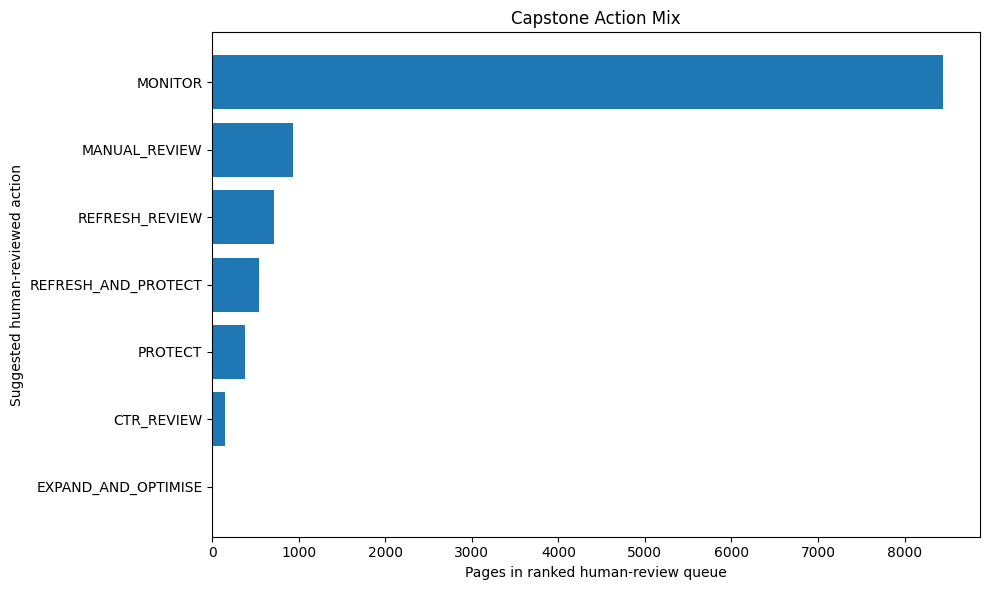

Saved: work/figures/capstone_action_mix.png


In [22]:
action_counts = (
    ranked_queue[
        "action_label"
    ]
    .value_counts()
    .sort_values(
        ascending=True
    )
)

plt.figure(
    figsize=(
        10,
        6,
    )
)

plt.barh(
    action_counts.index,
    action_counts.values,
)

plt.xlabel(
    "Pages in ranked human-review queue"
)

plt.ylabel(
    "Suggested human-reviewed action"
)

plt.title(
    "Capstone Action Mix"
)

plt.tight_layout()

action_mix_path = (
    FIGURE_DIR
    / "capstone_action_mix.png"
)

plt.savefig(
    action_mix_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    action_mix_path,
)

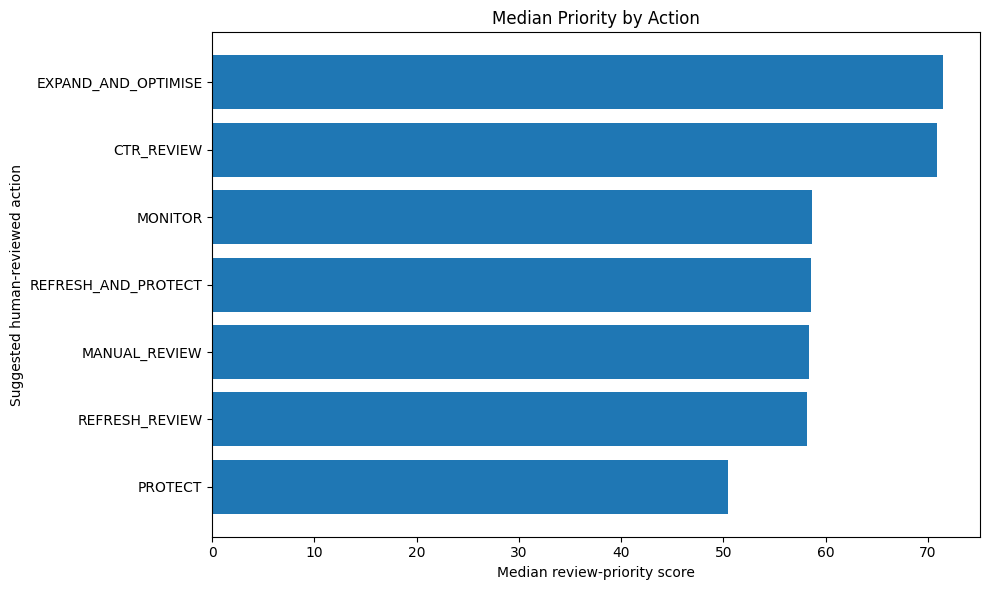

Saved: work/figures/capstone_priority_by_action.png


In [23]:
priority_by_action = (
    ranked_queue
    .groupby(
        "action_label",
        observed=True,
    )[
        "review_priority_score"
    ]
    .median()
    .sort_values(
        ascending=True
    )
)

plt.figure(
    figsize=(
        10,
        6,
    )
)

plt.barh(
    priority_by_action.index,
    priority_by_action.values,
)

plt.xlabel(
    "Median review-priority score"
)

plt.ylabel(
    "Suggested human-reviewed action"
)

plt.title(
    "Median Priority by Action"
)

plt.tight_layout()

priority_path = (
    FIGURE_DIR
    / "capstone_priority_by_action.png"
)

plt.savefig(
    priority_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    priority_path,
)

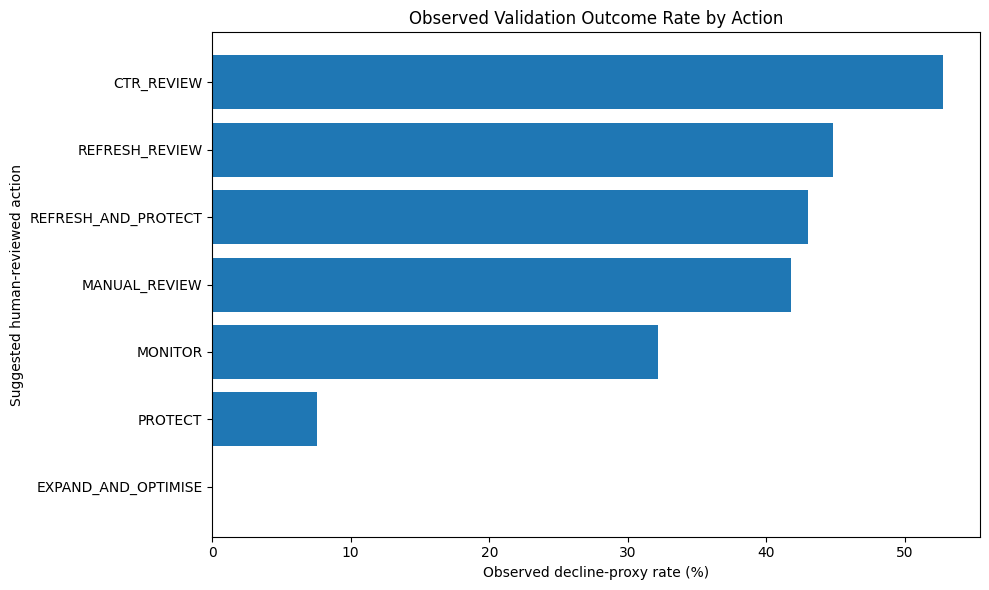

Saved: work/figures/capstone_observed_decline_by_action.png
This chart is observational and does not show the causal effect of taking an action.


In [24]:
decline_by_action = (
    ranked_queue
    .groupby(
        "action_label",
        observed=True,
    )
    .agg(
        observed_decline_rate=(
            target_column,
            "mean",
        ),
        pages=(
            target_column,
            "size",
        ),
    )
)

decline_by_action[
    "observed_decline_rate_pct"
] = (
    100
    *
    decline_by_action[
        "observed_decline_rate"
    ]
)

decline_by_action = (
    decline_by_action
    .sort_values(
        "observed_decline_rate_pct",
        ascending=True,
    )
)

plt.figure(
    figsize=(
        10,
        6,
    )
)

plt.barh(
    decline_by_action.index,
    decline_by_action[
        "observed_decline_rate_pct"
    ],
)

plt.xlabel(
    "Observed decline-proxy rate (%)"
)

plt.ylabel(
    "Suggested human-reviewed action"
)

plt.title(
    "Observed Validation Outcome Rate by Action"
)

plt.tight_layout()

decline_path = (
    FIGURE_DIR
    / "capstone_observed_decline_by_action.png"
)

plt.savefig(
    decline_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    decline_path,
)

print(
    "This chart is observational and does not "
    "show the causal effect of taking an action."
)

In [25]:
artifact_paths = [
    model_vs_baseline_path,
    importance_path,
    action_mix_path,
    priority_path,
    decline_path,
]

for source_path in artifact_paths:

    destination_path = (
        DOCS_ASSET_DIR
        /
        source_path.name
    )

    shutil.copy2(
        source_path,
        destination_path,
    )


artifact_manifest = pd.DataFrame(
    [
        {
            "artifact": (
                "Model vs baseline"
            ),
            "work_path": str(
                model_vs_baseline_path
            ),
            "docs_path": str(
                DOCS_ASSET_DIR
                /
                model_vs_baseline_path.name
            ),
            "paper_message": (
                "Model and baseline are compared "
                "on the same grouped holdout."
            ),
        },
        {
            "artifact": (
                "Permutation importance"
            ),
            "work_path": str(
                importance_path
            ),
            "docs_path": str(
                DOCS_ASSET_DIR
                /
                importance_path.name
            ),
            "paper_message": (
                "Importance describes model reliance "
                "and does not establish causation."
            ),
        },
        {
            "artifact": (
                "Action mix"
            ),
            "work_path": str(
                action_mix_path
            ),
            "docs_path": str(
                DOCS_ASSET_DIR
                /
                action_mix_path.name
            ),
            "paper_message": (
                "The queue distributes pages across "
                "transparent review actions."
            ),
        },
        {
            "artifact": (
                "Priority by action"
            ),
            "work_path": str(
                priority_path
            ),
            "docs_path": str(
                DOCS_ASSET_DIR
                /
                priority_path.name
            ),
            "paper_message": (
                "Priority combines model score, "
                "visibility, and data quality."
            ),
        },
        {
            "artifact": (
                "Observed outcome by action"
            ),
            "work_path": str(
                decline_path
            ),
            "docs_path": str(
                DOCS_ASSET_DIR
                /
                decline_path.name
            ),
            "paper_message": (
                "Observed differences are descriptive "
                "and not causal."
            ),
        },
    ]
)

display(
    artifact_manifest
)

artifact_manifest.to_csv(
    OUTPUT_DIR
    / "capstone_artifact_manifest.csv",
    index=False,
)

,artifact,work_path,docs_path,paper_message
0,Model vs baseline,work/figures/capstone_model_vs_baseline.png,docs/assets/capstone_model_vs_baseline.png,Model and baseline are compared on the same gr...
1,Permutation importance,work/figures/capstone_grouped_permutation_impo...,docs/assets/capstone_grouped_permutation_impor...,Importance describes model reliance and does n...
2,Action mix,work/figures/capstone_action_mix.png,docs/assets/capstone_action_mix.png,The queue distributes pages across transparent...
3,Priority by action,work/figures/capstone_priority_by_action.png,docs/assets/capstone_priority_by_action.png,"Priority combines model score, visibility, and..."
4,Observed outcome by action,work/figures/capstone_observed_decline_by_acti...,docs/assets/capstone_observed_decline_by_actio...,Observed differences are descriptive and not c...


In [26]:
paper_metrics = {
    "title": (
        "Prioritising Content Review "
        "with Leakage-Safe Machine Learning"
    ),
    "author": (
        "Zafar Ullah"
    ),
    "data_release": (
        "March 2026"
    ),
    "source_rows": int(
        source_check.loc[
            0,
            "total_rows",
        ]
    ),
    "operational_rows": int(
        len(
            model_frame
        )
    ),
    "validation_rows": int(
        len(
            validation_frame
        )
    ),
    "validation_clients": int(
        validation_frame[
            group_column
        ].nunique()
    ),
    "client_overlap": int(
        client_overlap
    ),
    "validation_base_rate": float(
        validation_base_rate
    ),
    "baseline_precision_at_50": float(
        baseline_precision_50
    ),
    "model_precision_at_50": float(
        model_precision_50
    ),
    "model_minus_baseline_precision_at_50": float(
        precision_difference
    ),
    "model_average_precision": float(
        model_result[
            "average_precision"
        ]
    ),
    "model_roc_auc": float(
        model_result[
            "roc_auc"
        ]
    ),
    "ranked_queue_rows": int(
        len(
            ranked_queue
        )
    ),
    "primary_metric": (
        "Precision@50"
    ),
    "automatic_action": False,
    "causal_claim": False,
    "human_review_required": True,
}

paper_metrics_path = (
    OUTPUT_DIR
    / "capstone_paper_metrics.json"
)

with paper_metrics_path.open(
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        paper_metrics,
        file,
        indent=2,
    )

print(
    "Saved paper metrics:",
    paper_metrics_path,
)

Saved paper metrics: work/outputs/capstone/capstone_paper_metrics.json


## Reproducibility

The public repository contains the analytical trail:

- Task framing: `work/notebooks/w02_ml_task_framing.ipynb`
- Transparent baseline: `work/notebooks/w04_baseline_score.ipynb`
- Model training: `work/notebooks/w05_model.ipynb`
- Validation audit: `work/notebooks/w06_validation_audit.ipynb`
- Action playbook: `work/notebooks/w07_action_playbook.ipynb`
- Final capstone: `work/notebooks/capstone.ipynb`

The core random seed is 42.

The queue CSV is regenerated by the notebook and may remain outside Git according to the repository leak guard.

Metrics JSON receipts and reusable figures should be committed.

## Acknowledgments & Data Credit

Built on the [FlyRank ML Internship dataset](https://flyrank.ai).

This project was completed as part of the FlyRank Machine Learning Internship.

The dataset, assignment structure, research guidance, and warehouse access were provided by FlyRank.

All public results use anonymised data and exclude client names, raw page URLs, and private queries.

In [27]:
required_notebooks = [
    Path(
        "work/notebooks/"
        "w02_ml_task_framing.ipynb"
    ),
    Path(
        "work/notebooks/"
        "w04_baseline_score.ipynb"
    ),
    Path(
        "work/notebooks/"
        "w05_model.ipynb"
    ),
    Path(
        "work/notebooks/"
        "w06_validation_audit.ipynb"
    ),
    Path(
        "work/notebooks/"
        "w07_action_playbook.ipynb"
    ),
    Path(
        "work/notebooks/"
        "capstone.ipynb"
    ),
]

reproducibility_receipt = pd.DataFrame(
    [
        {
            "path": str(
                notebook_path
            ),
            "exists": (
                notebook_path.exists()
            ),
        }
        for notebook_path
        in required_notebooks
    ]
)

display(
    reproducibility_receipt
)

ACKNOWLEDGMENT_TEXT = (
    "Built on the FlyRank ML Internship dataset. "
    "All public results use anonymised data and "
    "exclude client names, raw page URLs, and private queries."
)

assert (
    "FlyRank ML Internship dataset"
    in ACKNOWLEDGMENT_TEXT
)

print(
    ACKNOWLEDGMENT_TEXT
)

,path,exists
0,work/notebooks/w02_ml_task_framing.ipynb,True
1,work/notebooks/w04_baseline_score.ipynb,True
2,work/notebooks/w05_model.ipynb,True
3,work/notebooks/w06_validation_audit.ipynb,True
4,work/notebooks/w07_action_playbook.ipynb,True
5,work/notebooks/capstone.ipynb,True


Built on the FlyRank ML Internship dataset. All public results use anonymised data and exclude client names, raw page URLs, and private queries.


## Self-check

Before submission, this notebook confirms that:

- every section contains markdown reasoning and supporting code;
- the notebook runs top to bottom;
- model and baseline use the same grouped validation rows;
- grouped-client overlap is zero;
- base rate and Precision@50 are reported;
- target, future fields, identifiers, and existing scores are excluded from model features;
- ranked recommendations include reason codes;
- every exported recommendation requires human review;
- limitations and no-go cases are explicit;
- public tables exclude client names, raw URLs, and private queries;
- claims use observed, measured, directional, and decision-support language;
- paper figures and metrics receipts are exported;
- the abstract contains five sentences;
- the FlyRank acknowledgment and data credit are present.

In [28]:
required_output_files = [
    OUTPUT_DIR
    / "capstone_data_receipt.csv",

    OUTPUT_DIR
    / "capstone_model_vs_baseline.csv",

    OUTPUT_DIR
    / "capstone_permutation_importance.csv",

    OUTPUT_DIR
    / "capstone_results_metrics.json",

    OUTPUT_DIR
    / "capstone_limitations.csv",

    OUTPUT_DIR
    / "capstone_ranked_action_queue.csv",

    OUTPUT_DIR
    / "capstone_recommendation_summary.csv",

    OUTPUT_DIR
    / "capstone_action_playbook.json",

    OUTPUT_DIR
    / "capstone_artifact_manifest.csv",

    OUTPUT_DIR
    / "capstone_paper_metrics.json",

    model_path,

    model_vs_baseline_path,

    importance_path,

    action_mix_path,

    priority_path,

    decline_path,
]

public_table_columns = set(
    results_table.columns
).union(
    recommendation_summary.columns
).union(
    artifact_manifest.columns
)

careful_claim_language = (
    "observed measured directional "
    "decision-support human review "
    "does not establish causation"
).lower()

self_checks = {
    "Abstract contains exactly five sentences": (
        len(
            ABSTRACT_SENTENCES
        ) == 5
    ),

    "Research question is documented": (
        bool(
            RESEARCH_QUESTION.strip()
        )
    ),

    "Supported decision requires a human": (
        "human"
        in SUPPORTED_DECISION.lower()
    ),

    "Operational frame is non-empty": (
        len(
            model_frame
        ) > 0
    ),

    "Model and baseline use same validation rows": (
        len(
            model_scores
        )
        ==
        len(
            baseline_scores
        )
        ==
        len(
            validation_frame
        )
    ),

    "Grouped client overlap is zero": (
        client_overlap == 0
    ),

    "Results contain baseline and model": (
        set(
            results_table[
                "method"
            ]
        )
        ==
        {
            "Week-4 transparent baseline",
            "Logistic Regression",
        }
    ),

    "Validation base rate is valid": (
        0
        <= validation_base_rate
        <= 1
    ),

    "Baseline Precision@50 is valid": (
        0
        <= baseline_precision_50
        <= 1
    ),

    "Model Precision@50 is valid": (
        0
        <= model_precision_50
        <= 1
    ),

    "Target excluded from features": (
        target_column
        not in feature_columns
    ),

    "Group identifier excluded from features": (
        group_column
        not in feature_columns
    ),

    "Content identifier excluded from features": (
        "content_hash_id"
        not in feature_columns
    ),

    "Outcome fields excluded from features": (
        "outcome_impressions"
        not in feature_columns

        and

        "outcome_daily_impressions"
        not in feature_columns
    ),

    "Existing score excluded from features": (
        "baseline_action_score"
        not in feature_columns
    ),

    "Ranked queue is non-empty": (
        len(
            ranked_queue
        ) > 0
    ),

    "Queue ranks are sequential": (
        ranked_queue[
            "rank"
        ].tolist()
        ==
        list(
            range(
                1,
                len(
                    ranked_queue
                ) + 1,
            )
        )
    ),

    "Reason codes are populated": (
        ranked_queue[
            "reason_code"
        ]
        .astype(str)
        .str.len()
        .gt(0)
        .all()
    ),

    "Every exported action requires review": (
        ranked_queue[
            "human_review_required"
        ].eq(
            True
        ).all()
    ),

    "No automatic action": (
        playbook_receipt[
            "automatic_action"
        ]
        is False
    ),

    "No causal claim": (
        playbook_receipt[
            "causal_claim"
        ]
        is False
    ),

    "No monetary ROI claim": (
        playbook_receipt[
            "monetary_roi_claim"
        ]
        is False
    ),

    "Public tables exclude identifiers": (
        "client_hash_id"
        not in public_table_columns

        and

        "content_hash_id"
        not in public_table_columns
    ),

    "Careful claim language is present": all(
        phrase
        in careful_claim_language

        for phrase in [
            "observed",
            "measured",
            "directional",
            "decision-support",
            "human review",
        ]
    ),

    "Acknowledgment is present": (
        "FlyRank ML Internship dataset"
        in ACKNOWLEDGMENT_TEXT
    ),

    "Actual fitted model is saved": (
        hasattr(
            model,
            "predict_proba",
        )

        and

        model_path.exists()
    ),

    "All required outputs exist": all(
        path.exists()
        for path in required_output_files
    ),
}

self_check_df = pd.DataFrame(
    {
        "check": list(
            self_checks.keys()
        ),
        "passed": list(
            self_checks.values()
        ),
    }
)

display(
    self_check_df
)

failed_checks = [
    check_name

    for check_name, passed
    in self_checks.items()

    if not passed
]

if failed_checks:

    raise AssertionError(
        "Self-check failed: "
        +
        ", ".join(
            failed_checks
        )
    )

final_receipt = {
    "assignment": (
        "Capstone research paper notebook"
    ),
    "all_self_checks_passed": True,
    "public_safe": True,
    "model_vs_baseline_same_split": True,
    "client_overlap": int(
        client_overlap
    ),
    "primary_metric": (
        "Precision@50"
    ),
    "paper_assets_directory": str(
        DOCS_ASSET_DIR
    ),
    "submission_url_file_required": (
        "submission/paper_url.txt"
    ),
}

with (
    OUTPUT_DIR
    / "capstone_final_receipt.json"
).open(
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        final_receipt,
        file,
        indent=2,
    )

print(
    "Saved capstone outputs:",
    OUTPUT_DIR,
)

print(
    "Saved paper figures:",
    FIGURE_DIR,
)

print(
    "Copied deployment assets:",
    DOCS_ASSET_DIR,
)

print(
    "All capstone self-checks passed."
)

,check,passed
0,Abstract contains exactly five sentences,True
1,Research question is documented,True
2,Supported decision requires a human,True
3,Operational frame is non-empty,True
4,Model and baseline use same validation rows,True
5,Grouped client overlap is zero,True
6,Results contain baseline and model,True
7,Validation base rate is valid,True
8,Baseline Precision@50 is valid,True
9,Model Precision@50 is valid,True


Saved capstone outputs: work/outputs/capstone
Saved paper figures: work/figures
Copied deployment assets: docs/assets
All capstone self-checks passed.
